### 2025 T3 Lab 4 Specification
 Author: SongyuQi
 
 ZID: z5536858

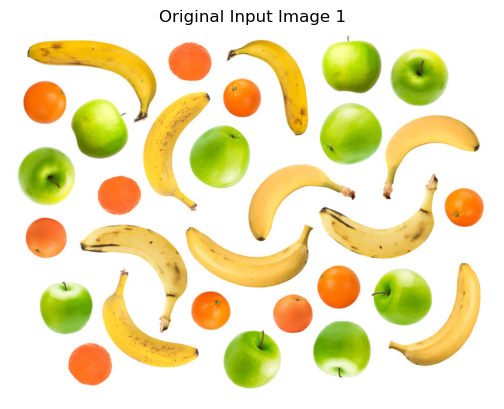

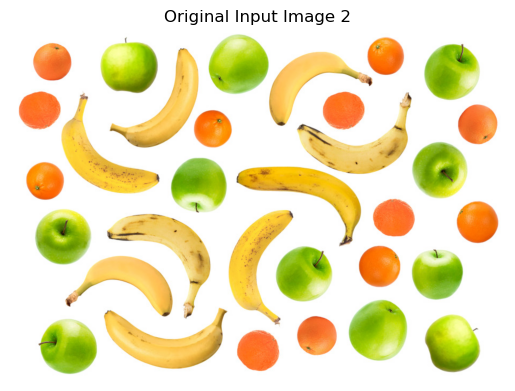

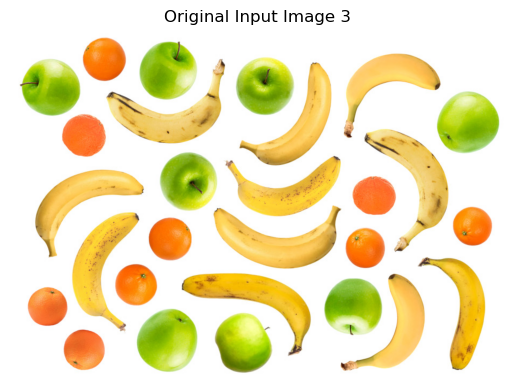

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def display_image(image, title='Image', cmap_type='gray'):
    if len(image.shape) == 3 and image.shape[2] == 3:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(image_rgb)
    else:
        plt.imshow(image, cmap=cmap_type)
        
    plt.title(title)
    plt.axis('off') 
    plt.show()

N_TARGET = 10
SEG_THRESHOLD = 240
MORPH_KERNEL_SIZE = (5, 5) 
BANANA_ASPECT_RATIO_MIN = 1.5
# H in Opencv from 0-179
# Orange (Mandarins) = 5-25
# Green (Apples) = 30-80
# Yellow (<= 35) and Green (> 35)
#HUE_APPLE_MANDARIN_THRESHOLD = 28
HUE_THRESH_ORANGE_YELLOW = 20 
HUE_THRESH_YELLOW_GREEN = 30

image_folder = './COMP9517_25T3_Lab4_Images'
images_bgr = [cv2.imread(os.path.join(image_folder, f), cv2.IMREAD_COLOR)
 for f in sorted(os.listdir(image_folder)) 
 if f.endswith('.jpg')]

for i in range(len(images_bgr)):
    display_image(images_bgr[i], title=f'Original Input Image {i+1}')

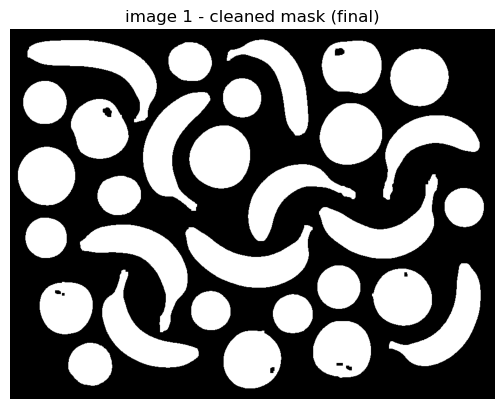

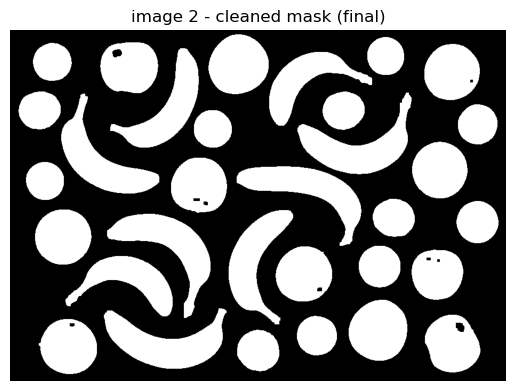

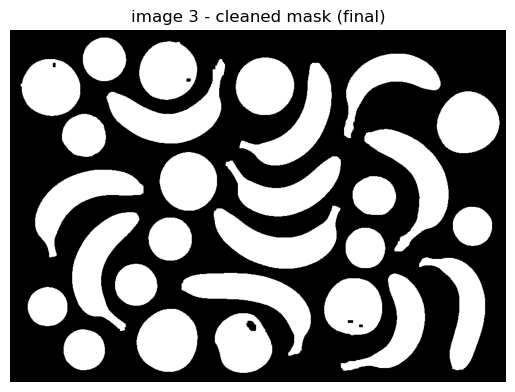

In [4]:
morph_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, MORPH_KERNEL_SIZE)
processed_masks = []
for i, image_bgr in enumerate(images_bgr):
    image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    
    # pix < 240 (SEG_THRESHOLD) to 255 (white/foreground)
    # pix >= 240 (SEG_THRESHOLD) to 0 (black/background)
    _, mask_original = cv2.threshold(image_gray, 
                                     SEG_THRESHOLD, 
                                     255, 
                                     cv2.THRESH_BINARY_INV)
    
    # Opening: remove small noise pixels
    mask_opened = cv2.morphologyEx(mask_original, cv2.MORPH_OPEN, morph_kernel)
    
    # Closing: fill holes inside the object
    mask_cleaned = cv2.morphologyEx(mask_opened, cv2.MORPH_CLOSE, morph_kernel)

    processed_masks.append(mask_cleaned)
    display_image(mask_cleaned, title=f'image {i+1} - cleaned mask (final)')

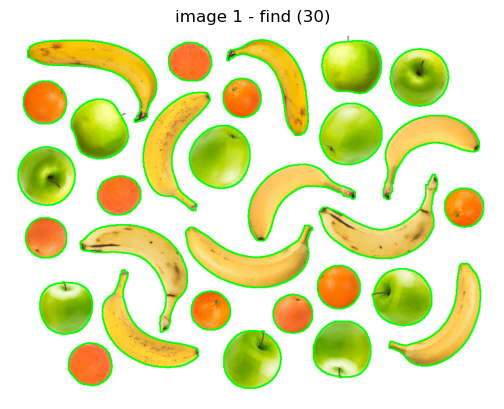

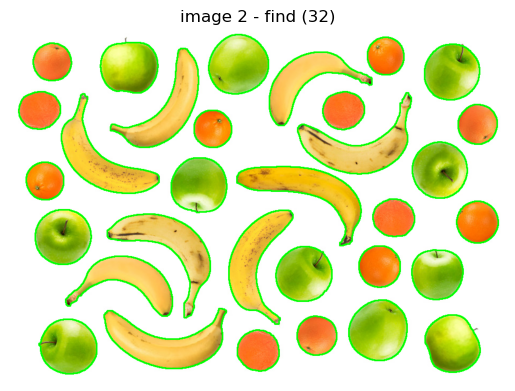

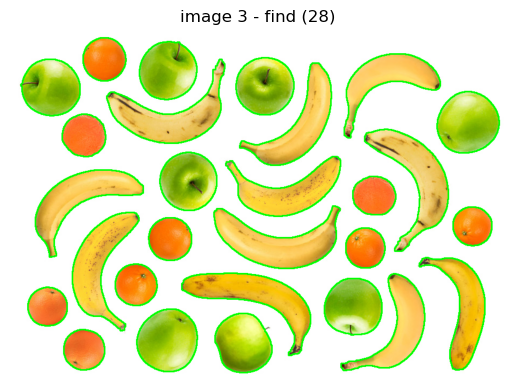

In [5]:
all_contours_list = []
visualization_images = []

for i, mask in enumerate(processed_masks):
    contours, hierarchy = cv2.findContours(mask.copy(), 
                                             cv2.RETR_EXTERNAL, 
                                             cv2.CHAIN_APPROX_SIMPLE)
    
    all_contours_list.append(contours)
    image_with_contours = images_bgr[i].copy()
    cv2.drawContours(image_with_contours, contours, -1, (0, 255, 0), 2)
    
    visualization_images.append(image_with_contours)
    display_image(image_with_contours, title=f'image {i+1} - find ({len(contours)})')

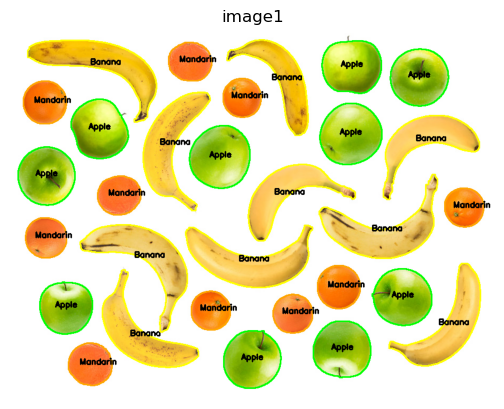

--- from the image1 find:---
  Apples:10; Bananas:10; Mandarins:10

  All good


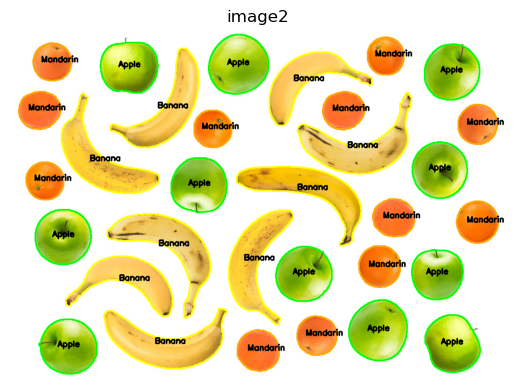

--- from the image2 find:---
  Apples:11; Bananas:9; Mandarins:12

  Remove 1 apples
  Add 1 bananas
  Remove 2 mandarins


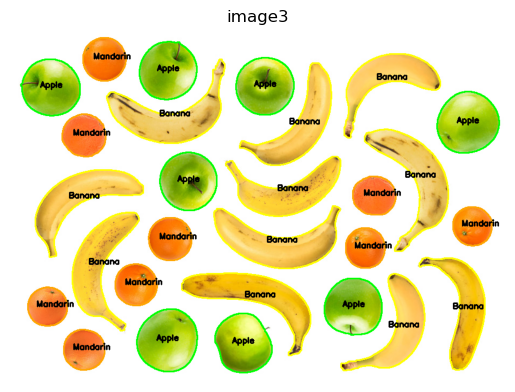

--- from the image3 find:---
  Apples:8; Bananas:11; Mandarins:9

  Add 2 apples
  Remove 1 bananas
  Add 1 mandarins


In [6]:

for i, (image_bgr, mask, contours) in enumerate(zip(images_bgr, processed_masks, all_contours_list)):
    image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    image_classified = image_bgr.copy()
    
    count_apples = 0
    count_bananas = 0
    count_mandarins = 0

    for contour in contours:

        (x, y), (width, height), angle = cv2.minAreaRect(contour)
        aspect_ratio = max(width, height) / min(width, height) if min(width, height) > 0 else 0
        
        is_elongated = aspect_ratio > BANANA_ASPECT_RATIO_MIN #not like circle
        mask_single = np.zeros(mask.shape, dtype="uint8")
        cv2.drawContours(mask_single, [contour], -1, 255, -1) 
        
        mean_hsv = cv2.mean(image_hsv, mask=mask_single)
        mean_hue = mean_hsv[0] 
        
        is_orange = mean_hue < HUE_THRESH_ORANGE_YELLOW   # < 20
        is_yellow = (mean_hue >= HUE_THRESH_ORANGE_YELLOW) and (mean_hue <= HUE_THRESH_YELLOW_GREEN) # 20-30
        is_green = mean_hue > HUE_THRESH_YELLOW_GREEN    # > 30
        
        label = "Unclassified"
        color = (255, 0, 255) #initial
        if is_elongated and is_yellow: #rule1: not like circle and yellow
            count_bananas += 1
            label = "Banana"
            color = (0, 255, 255) # yellow
        elif (not is_elongated) and is_green: #rule2: like circle and green
            count_apples += 1
            label = "Apple"
            color = (0, 255, 0) # green
        elif (not is_elongated) and is_orange: #rule3: like circle and orange
            count_mandarins += 1
            label = "Mandarin"
            color = (0, 165, 255) # orange
        
        elif (not is_elongated) and is_yellow: #rule4: like circle and yellow
            count_apples += 1
            label = "Apple (Yellowish)"
            color = (0, 255, 0) # green
        elif is_elongated and is_green: #rule5: not like circle and green
            count_apples += 1
            label = "Apple (Long)"
            color = (0, 255, 0) # green
        elif is_elongated and is_orange: #rule6: not like circle and orange
            count_bananas += 1
            label = "Banana (Orangeish)"
            color = (0, 255, 255) # Yellow
        
        cv2.drawContours(image_classified, [contour], -1, color, 2)
        M = cv2.moments(contour)
        if M["m00"] > 0:
             cX = int(M["m10"] / M["m00"])
             cY = int(M["m01"] / M["m00"])
             cv2.putText(image_classified, label, (cX - 20, cY), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

    display_image(image_classified, title=f'image{i+1}')
    print(f"--- from the image{i+1} find:---")
    print(f"  Apples:{count_apples}; Bananas:{count_bananas}; Mandarins:{count_mandarins}\n")
    diff_apples = N_TARGET - count_apples
    diff_bananas = N_TARGET - count_bananas
    diff_mandarins = N_TARGET - count_mandarins
    
    needs_correction = False
    
    if diff_apples > 0:
        print(f"  Add {diff_apples} apples")
        needs_correction = True
    elif diff_apples < 0:
        print(f"  Remove {-diff_apples} apples")
        needs_correction = True
        
    if diff_bananas > 0:
        print(f"  Add {diff_bananas} bananas")
        needs_correction = True
    elif diff_bananas < 0:
        print(f"  Remove {-diff_bananas} bananas")
        needs_correction = True
        
    if diff_mandarins > 0:
        print(f"  Add {diff_mandarins} mandarins")
        needs_correction = True
    elif diff_mandarins < 0:
        print(f"  Remove {-diff_mandarins} mandarins")
        needs_correction = True
        
    if not needs_correction:
        print("  All good")
